In [241]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import os

In [242]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.pipeline import Pipeline

In [243]:
os.getcwd()

'C:\\Users\\gokhan\\anaconda_projects\\MLNotebooks'

In [244]:
os.chdir(r"C:\Users\gokhan\anaconda_projects\MLNotebooks")

In [245]:
df = pd.read_csv("3-customersatisfaction.csv")

In [246]:
df.head()

,Unnamed: 0,Customer Satisfaction,Incentive
0,0,-1.282447,1.010513
1,1,0.425298,2.281043
2,2,1.953070,4.415053
3,3,2.625838,10.563600
4,4,-1.426333,0.627365


In [247]:
df.drop("Unnamed: 0", axis=1, inplace=True)

In [248]:
df.head()

,Customer Satisfaction,Incentive
0,-1.282447,1.010513
1,0.425298,2.281043
2,1.953070,4.415053
3,2.625838,10.563600
4,-1.426333,0.627365


In [249]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer Satisfaction  100 non-null    float64
 1   Incentive              100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB


In [250]:
df.describe()

,Customer Satisfaction,Incentive
count,100.000000,100.000000
mean,-0.005427,3.445220
std,1.721792,2.911818
min,-2.992863,-1.068081
25%,-1.431357,1.471341
50%,0.109167,2.748839
75%,1.421119,4.739113
max,2.986736,11.000056


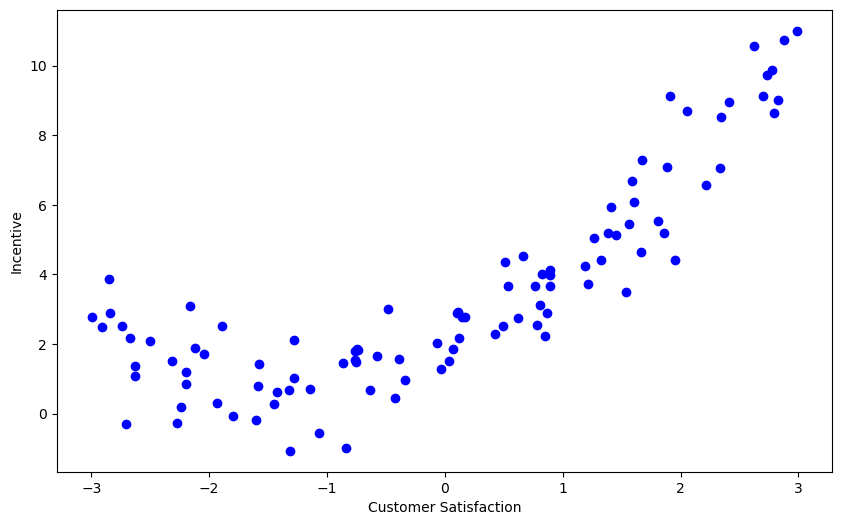

In [251]:
plt.figure(figsize=(10,6))
plt.scatter(df["Customer Satisfaction"], df["Incentive"], color="b")
plt.xlabel("Customer Satisfaction")
plt.ylabel("Incentive")
plt.show()

In [252]:
# Independent and dependent features

In [253]:
X = df[["Customer Satisfaction"]]
y = df["Incentive"]

In [254]:
X.head()

,Customer Satisfaction
0,-1.282447
1,0.425298
2,1.953070
3,2.625838
4,-1.426333


In [255]:
y.head()

0     1.010513
1     2.281043
2     4.415053
3    10.563600
4     0.627365
Name: Incentive, dtype: float64

In [256]:
# train - test split

In [257]:
X_train, X_test , y_train , y_test = train_test_split(X,y,test_size=0.2, random_state=15)

In [258]:
# Scaler

In [259]:
scaler = StandardScaler()

In [260]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [261]:
# Regression

In [262]:
regression = LinearRegression()

In [263]:
regression.fit(X_train, y_train)

LinearRegression()

In [264]:
# Prediction

In [265]:
y_pred = regression.predict(X_test)

In [266]:
y_pred

array([ 4.65663741,  3.71913877,  1.64121789,  6.29646523,  3.46766736,
        5.7580845 ,  4.692485  ,  3.61616231,  5.62448003,  0.13472702,
        4.47909659,  4.8130839 ,  1.58319087,  0.30515983,  5.27634309,
        0.41711005, -0.7385295 , -0.32653914,  3.55906887,  1.19798631])

In [267]:
score = r2_score(y_test, y_pred)
print(score)

0.27056525356222416


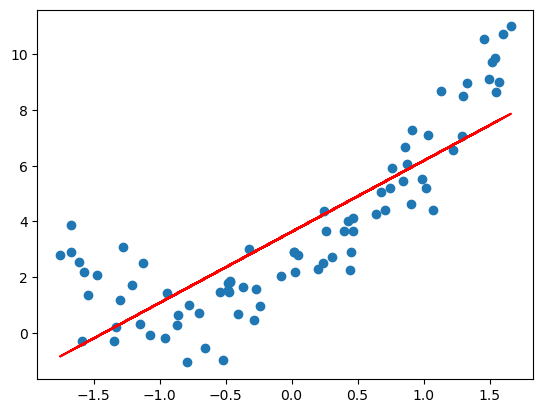

In [268]:
plt.scatter(X_train,y_train)
plt.plot(X_train, regression.predict(X_train),color = "r")
plt.show()

In [269]:
poly = PolynomialFeatures(degree=2, include_bias=True)

In [270]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [271]:
regression = LinearRegression()
regression.fit(X_train_poly,y_train)

LinearRegression()

In [272]:
y_pred = regression.predict(X_test_poly)

In [273]:
score = r2_score(y_test,y_pred)  
print(score)

0.7685687698788557


In [274]:
regression.coef_

array([0.        , 2.63871762, 1.54959954])

In [275]:
regression.intercept_

np.float64(2.07667642979328)

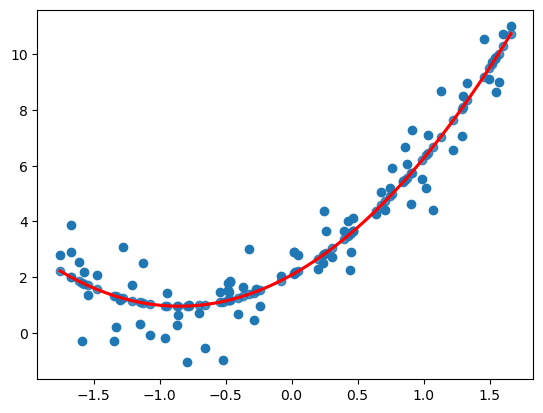

In [276]:
plt.scatter(X_train,y_train)
sns.regplot(x=X_train, y=regression.predict(X_train_poly), order=2, line_kws={"color": "red"})
plt.show()

In [277]:
poly3 = PolynomialFeatures(degree=3,include_bias=True)

In [278]:
X_train_poly3 = poly3.fit_transform(X_train)
X_test_poly3 = poly3.transform(X_test)

In [279]:
regression_3 = LinearRegression()

In [280]:
regression_3.fit(X_train_poly3,y_train)

LinearRegression()

In [281]:
y_pred_3 = regression_3.predict(X_test_poly3)

In [282]:
print(r2_score(y_test,y_pred_3))

0.7573443621401051


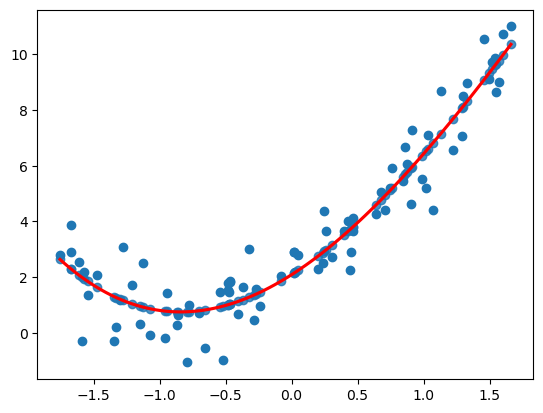

In [283]:
plt.scatter(X_train,y_train)
sns.regplot(x=X_train,y=regression_3.predict(X_train_poly3),order=3,line_kws={"color":"red"})
plt.show()

In [284]:
# It makes more sense to keep it at degree 2

In [285]:
new_df = pd.read_csv("3-newdatas.csv")

In [286]:
new_df.head()

,0
0,-3.000000
1,-2.969849
2,-2.939698
3,-2.909548
4,-2.879397


In [287]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       200 non-null    float64
dtypes: float64(1)
memory usage: 1.7 KB


In [288]:
new_df.rename(columns = {"0": "Customer Satisfaction"}, inplace=True)

In [289]:
X_new = new_df[["Customer Satisfaction"]]

In [290]:
X_new = scaler.transform(X_new)

In [291]:
X_new_poly = poly.transform(X_new)

In [293]:
y_new = regression.predict(X_new_poly)

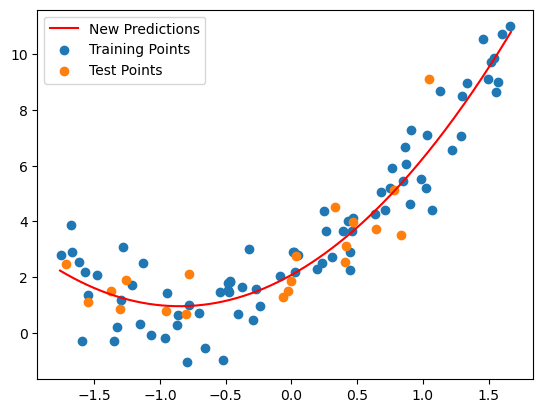

In [298]:
plt.plot(X_new, y_new, "r", label="New Predictions")
plt.scatter(X_train, y_train, label="Training Points")
plt.scatter(X_test, y_test, label="Test Points")
plt.legend()
plt.show()

In [299]:
#Pipeline

In [320]:
def poly_regression(degree):
    standart_scaler = StandardScaler()
    poly_features = PolynomialFeatures(degree=degree)
    lin_reg = LinearRegression()
    pipeline = Pipeline([
        ("standart_scaler",standart_scaler),    
        ("poly_features",poly_features),
        ("lin_reg",lin_reg),
        ])
    pipeline.fit(X_train,y_train)
    score = pipeline.score(X_test,y_test)
    print(f"{degree} degree R2: ",score)

In [321]:
poly_regression(1)

1 degree R2:  0.2705652535622246


In [322]:
poly_regression(2)

2 degree R2:  0.7685687698788557


In [323]:
poly_regression(3)

3 degree R2:  0.757344362140105


In [324]:
for degree in [1,2,3,4,5,6,7,8,9,10]:
    poly_regression(degree)

1 degree R2:  0.2705652535622246
2 degree R2:  0.7685687698788557
3 degree R2:  0.757344362140105
4 degree R2:  0.7355034443260415
5 degree R2:  0.7351244165095399
6 degree R2:  0.7343590482133431
7 degree R2:  0.7347819263549453
8 degree R2:  0.7411422099998393
9 degree R2:  0.7310763879815925
10 degree R2:  0.7280578621232858


In [325]:
def poly_regression(degree):
    poly_features = PolynomialFeatures(degree=degree)
    lin_reg = LinearRegression()
    scaler = StandardScaler()
    pipeline = Pipeline([
        ("standard_scaler", scaler),
        ("poly_features", poly_features),
        ("lin_reg", lin_reg)
    ])
    pipeline.fit(X_train, y_train)
    score = pipeline.score(X_test, y_test)
    print("R2 score: ", score)

    y_pred_new = pipeline.predict(X_new)
    plt.plot(X_new, y_pred_new, "r", label="New Predictions")
    plt.scatter(X_train, y_train, label="Training Points")
    plt.scatter(X_test, y_test, label="Test Points")
    plt.legend()
    plt.show()

R2 score:  0.2705652535622246


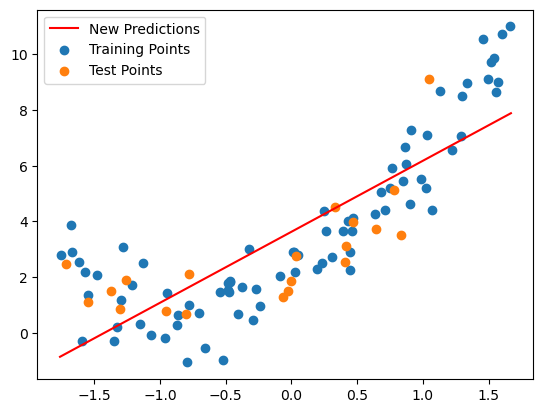

R2 score:  0.7685687698788557


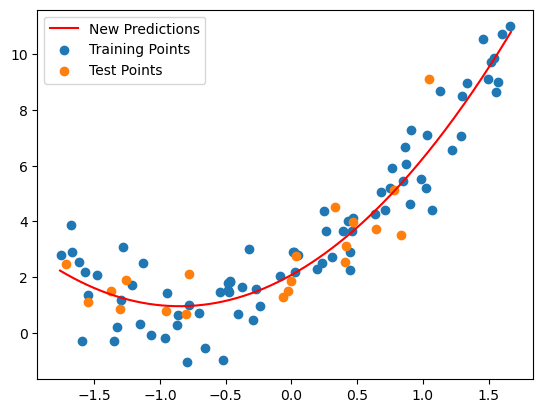

R2 score:  0.757344362140105


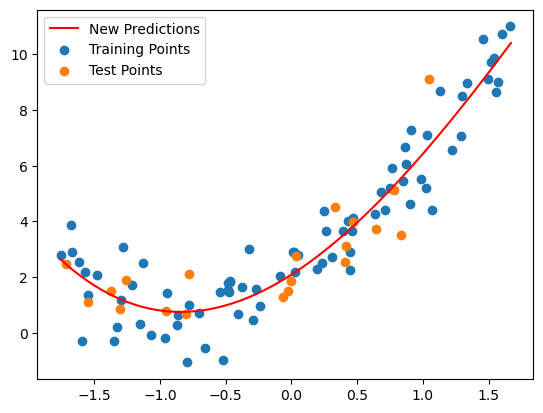

R2 score:  0.7355034443260415


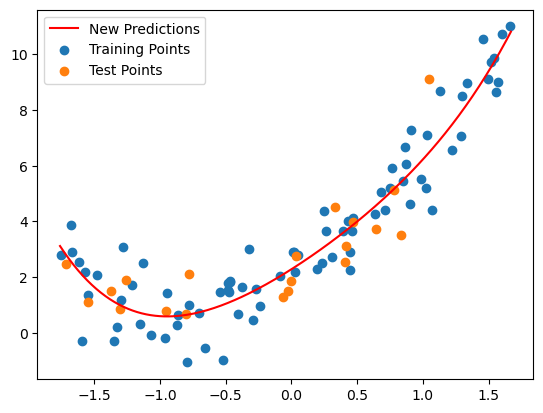

R2 score:  0.7351244165095399


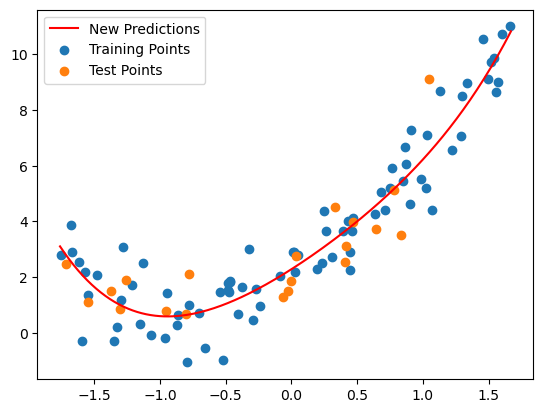

R2 score:  0.7343590482133431


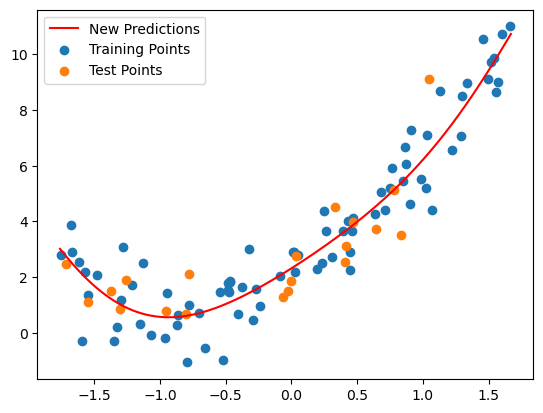

R2 score:  0.7347819263549453


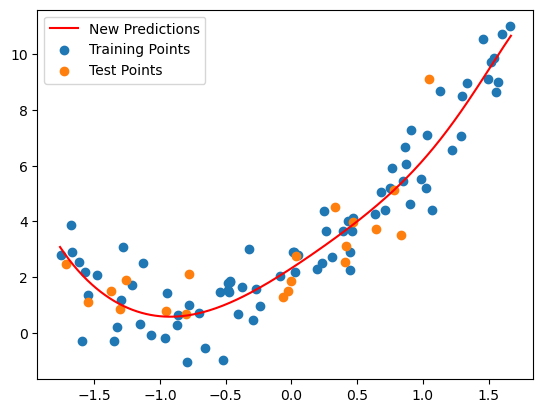

R2 score:  0.7411422099998393


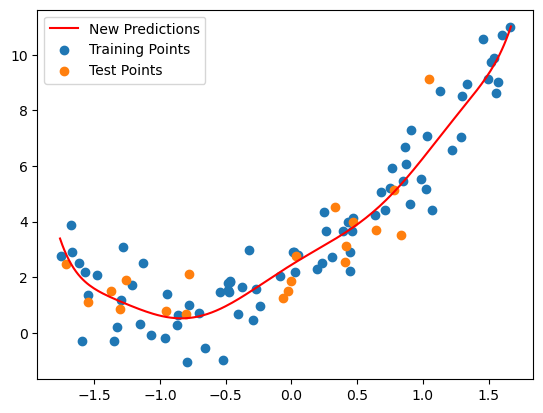

R2 score:  0.7310763879815925


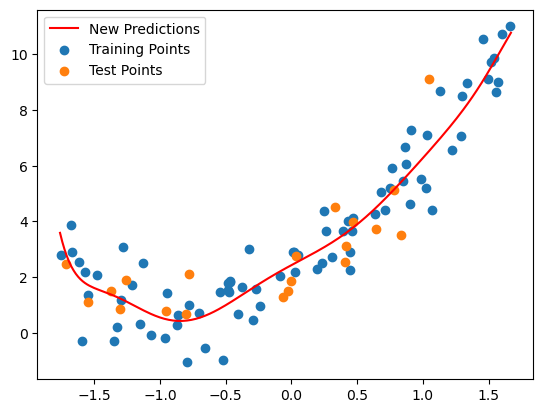

R2 score:  0.7280578621232858


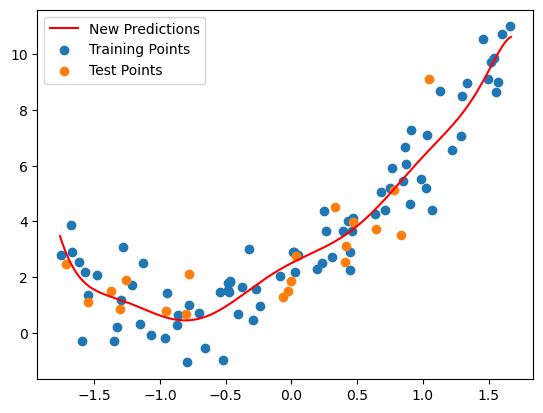

R2 score:  0.321427232814399


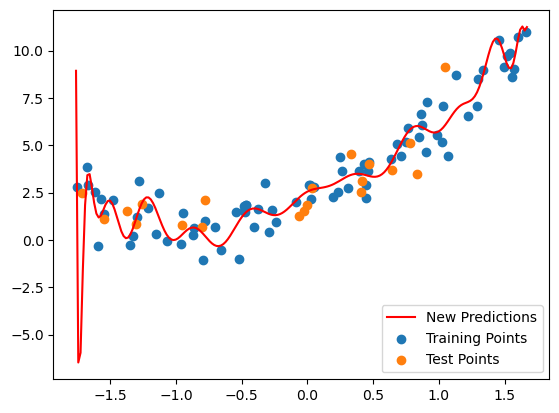

In [329]:
for degree in [1,2,3,4,5,6,7,8,9,10,25]:
    poly_regression(degree)